# PROJETO PARCIAL – ATIVIDADE 1: Análise Exploratória e Engenharia de Dados (VRA/ANAC)
**Disciplina:** Introdução ao Machine Learning  
**Curso:** Mestrado em Administração Pública — Ciência de Dados e Inteligência Artificial (IDP)  
**Docente Responsável:** Profa. Dra. Roberta Moreira Wichmann  
**Discentes:** Francisco Fonseca, Lucimar Nascimento, Osvaldo Souza  
**Representante do Grupo (Padrão de Arquivos):** Lucimar Nascimento  

---

## 1. Contextualização do Problema e Definição das Variáveis Alvo (Targets)
- **Problema de Gestão e Regulação Pública:** A pontualidade operacional dos voos comerciais regulares constitui um indicador crítico de eficiência da infraestrutura aeroviária e de proteção aos direitos dos passageiros (Resolução ANAC nº 400). Prever a magnitude do atraso na partida permite à administração pública atuar preventivamente na fiscalização de *slots* e na mitigação do efeito cascata na malha aérea.
- **Fonte dos Dados:** Microdados públicos brutos do registro de Voo Regular Ativo (VRA), extraídos do repositório SIROS da Agência Nacional de Aviação Civil (ANAC) e consolidados localmente no arquivo `base_lucimar_nascimento.csv`.
- **Tarefa de Aprendizado Supervisionado:** Classificação Multiclasse Ordinal (alvo principal) combinada com Classificação Binária (alvo secundário de *benchmark*).
- **Variável Target Principal (`faixa_atraso_partida` / `codigo_faixa_atraso`):** Categorização ordinal do tempo líquido de atraso na partida (`atraso_partida_minutos`) em **6 faixas operacionais**:
  - **`0` — Pontual ou antecipado:** atraso $\le 0$ minutos (voo partiu no horário exato ou adiantado);
  - **`1` — Atraso inferior a 15 min:** $0 < \text{atraso} < 15$ minutos (margem de tolerância operacional internacional IATA/ANAC);
  - **`2` — Atraso de 15 a 30 min:** $15 \le \text{atraso} \le 30$ minutos;
  - **`3` — Atraso superior a 30 até 45 min:** $30 < \text{atraso} \le 45$ minutos;
  - **`4` — Atraso superior a 45 até 60 min:** $45 < \text{atraso} \le 60$ minutos;
  - **`5` — Atraso superior a 60 min:** $\text{atraso} > 60$ minutos (atrasos críticos/severos sujeitos a obrigações escalonadas de assistência material).
- **Variável Target Secundária (`atraso_bi`):** Indicador binário onde `1` representa atraso comercial oficial ($\ge 15$ minutos, equivalente às faixas 2 a 5) e `0` representa voo pontual ($< 15$ minutos, equivalente às faixas 0 e 1).

In [1]:
# ==============================================================================
# CÉLULA 2: Importação das Bibliotecas Padrão (Ambiente Anaconda)
# ==============================================================================
import os
import sys
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supressão de avisos de depreciação para manter o relatório limpo para avaliação
warnings.filterwarnings('ignore')

# Configuração de estilo gráfico com fallback seguro entre versões do Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 30)

print("Ambiente configurado com sucesso!")
print(f"Versão do Python : {sys.version.split()[0]}")
print(f"Versão do Pandas : {pd.__version__}")
print(f"Versão do NumPy  : {np.__version__}")

Ambiente configurado com sucesso!
Versão do Python : 3.14.6
Versão do Pandas : 3.0.3
Versão do NumPy  : 2.4.6


In [2]:
# ==============================================================================
# CÉLULA 3: Leitura Resiliente da Base de Dados Bruta Local
# ==============================================================================
# O código busca o arquivo oficial 'base_lucimar_nascimento.csv' na pasta atual
# ou em subdiretórios locais do projeto, garantindo execução 100% offline.

nome_padrao = "base_lucimar_nascimento_v2.csv"
caminhos_candidatos = [
    nome_padrao,
    os.path.join("data", nome_padrao),
    os.path.join("data", "raw", "VRA_2025_01.csv"),
    os.path.join("data", "amostra_vra_2024_2025.csv"),
    os.path.join("..", nome_padrao)
]

caminho_base = next((p for p in caminhos_candidatos if os.path.exists(p)), None)

if caminho_base is None:
    csvs_locais = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    if csvs_locais:
        caminho_base = csvs_locais[0]
    else:
        raise FileNotFoundError(
            f"Arquivo '{nome_padrao}' não localizado. Coloque o CSV na mesma pasta deste notebook."
        )

print(f"Arquivo localizado para leitura: {caminho_base}")

# Tratamento de codificação (arquivos brutos do SIROS/ANAC usam Latin-1/CP1252 ou UTF-8 com header extra)
df_bruto = None
for enc in ['utf-8-sig', 'latin1', 'cp1252', 'iso-8859-1', 'utf-8']:
    for sep_teste in [';', ',']:
        try:
            # Verifica se a primeira linha do CSV bruto da ANAC é o título " Atualizado em: ..."
            with open(caminho_base, 'r', encoding=enc, errors='strict') as f:
                primeira_linha = f.readline()
            pular_linhas = 1 if 'atualizado em' in primeira_linha.lower() else 0
            
            temp = pd.read_csv(caminho_base, sep=sep_teste, encoding=enc, skiprows=pular_linhas, low_memory=False)
            if temp.shape[1] > 3:
                df_bruto = temp
                print(f"Leitura concluída: encoding='{enc}' | separador='{sep_teste}' | skiprows={pular_linhas}")
                break
        except Exception:
            continue
    if df_bruto is not None:
        break

if df_bruto is None:
    raise RuntimeError("Não foi possível decodificar o arquivo CSV. Verifique a integridade do arquivo.")

print(f"Dimensões originais da base lida: {df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas.")
display(df_bruto.head(3))

Arquivo localizado para leitura: base_lucimar_nascimento_v2.csv
Leitura concluída: encoding='utf-8-sig' | separador=',' | skiprows=0
Dimensões originais da base lida: 1,992,832 linhas x 25 colunas.


,companhia_icao,empresa,numero_voo,codigo_di,codigo_tipo_linha,modelo_equipamento,numero_assentos,origem_icao,origem_descricao,partida_prevista,partida_real,destino_icao,destino_descricao,chegada_prevista,chegada_real,situacao_voo,situacao_partida,situacao_chegada,codeshare,cancelado,realizado,atraso_partida_min,atraso_chegada_min,arquivo_origem,linha_origem
0,AAL,"AMERICAN AIRLINES, INC.",0904,0,I,B772,288,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,2024-01-01 23:55:00,2024-01-01 23:47:00,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-02 07:45:00,2024-01-02 08:19:00,REALIZADO,Antecipado,Atraso 30-60,GLO/6004,False,True,-8.0,34.0,VRA_2024_01.csv,1
1,AAL,"AMERICAN AIRLINES, INC.",0905,0,I,B772,288,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 23:55:00,2024-01-01 01:29:00,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,2024-01-02 09:25:00,2024-01-01 09:35:00,REALIZADO,Antecipado,Antecipado,GLO/6005,False,True,-1346.0,-1430.0,VRA_2024_01.csv,2
2,AAL,"AMERICAN AIRLINES, INC.",0906,0,I,B77W,318,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,2024-01-01 00:55:00,2024-01-01 00:46:00,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 08:35:00,2024-01-01 08:45:00,REALIZADO,Antecipado,Pontual,GLO/6006,False,True,-9.0,10.0,VRA_2024_01.csv,3


## 2. Padronização de Esquema (Da Base Bruta SIROS/ANAC para o Dicionário Analítico)
Nos arquivos brutos disponibilizados pela ANAC (`/siros/registros/diversos/vra/`), os cabeçalhos originais podem vir com espaços, acentos ou siglas abreviadas (ex.: `Sigla ICAO Empresa Aérea`, `Código Justificativa`, `Partida Prevista`, `Situação Voo`). 

Na célula a seguir, aplicamos uma função de **normalização e mapeamento determinístico de colunas** que converte qualquer variante do cabeçalho bruto do SIROS/ANAC para a nomenclatura padronizada no `dicionario_lucimar_nascimento.xlsx`, preservando os dados brutos originais e garantindo total rastreabilidade.

In [3]:
# ==============================================================================
# CÉLULA 5: Padronização e Mapeamento de Colunas da Base Bruta SIROS/ANAC
# ==============================================================================
df = df_bruto.copy()

# Função auxiliar para remover acentos e padronizar nomes brutos em snake_case
def normalizar_nome_coluna(col):
    col_sem_acento = ''.join(
        c for c in unicodedata.normalize('NFKD', str(col))
        if not unicodedata.combining(c)
    )
    col_limpa = col_sem_acento.strip().lower()
    for ch in [' ', '-', '/', '.', '(', ')']:
        col_limpa = col_limpa.replace(ch, '_')
    while '__' in col_limpa:
        col_limpa = col_limpa.replace('__', '_')
    return col_limpa.strip('_')

df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Lista ordenada por prioridade: mapeia apenas a primeira ocorrência de cada variável
regras_mapeamento = [
    ('sg_empresa_icao', ['sigla_icao_empresa_aerea', 'icao_empresa_aerea', 'sg_empresa_icao', 'empresa_aerea', 'cia_aerea']),
    ('nr_voo', ['numero_voo', 'nr_voo', 'num_voo', 'voo']),
    ('sg_icao_origem', ['sigla_icao_aeroporto_origem', 'codigo_icao_aerodromo_origem', 'sg_icao_origem', 'icao_origem', 'aeroporto_origem', 'origem']),
    ('sg_icao_destino', ['sigla_icao_aeroporto_destino', 'codigo_icao_aerodromo_destino', 'sg_icao_destino', 'icao_destino', 'aeroporto_destino', 'destino']),
    ('dt_partida_prevista', ['partida_prevista', 'dt_partida_prevista', 'data_partida_prevista']),
    ('dt_partida_real', ['partida_real', 'dt_partida_real', 'data_partida_real']),
    ('dt_chegada_prevista', ['chegada_prevista', 'dt_chegada_prevista', 'data_chegada_prevista']),
    ('dt_chegada_real', ['chegada_real', 'dt_chegada_real', 'data_chegada_real']),
    ('cd_situacao_voo', ['situacao_voo', 'cd_situacao_voo', 'status_voo', 'situacao_partida']),
    ('atraso_partida_minutos', ['atraso_partida_minutos', 'partida_atraso_minutos'])
]

colunas_renomeadas = {}
for nome_padrao, candidatas in regras_mapeamento:
    if nome_padrao not in df.columns:
        for cand in candidatas:
            if cand in df.columns and cand not in colunas_renomeadas:
                colunas_renomeadas[cand] = nome_padrao
                break

df = df.rename(columns=colunas_renomeadas)

# Remove eventuais colunas duplicadas preservando a primeira ocorrência
df = df.loc[:, ~df.columns.duplicated()].copy()

print("Colunas após padronização de esquema (sem duplicidades):")
print(list(df.columns))

Colunas após padronização de esquema (sem duplicidades):
['companhia_icao', 'empresa', 'nr_voo', 'codigo_di', 'codigo_tipo_linha', 'modelo_equipamento', 'numero_assentos', 'origem_icao', 'origem_descricao', 'dt_partida_prevista', 'dt_partida_real', 'destino_icao', 'destino_descricao', 'dt_chegada_prevista', 'dt_chegada_real', 'cd_situacao_voo', 'situacao_partida', 'situacao_chegada', 'codeshare', 'cancelado', 'realizado', 'atraso_partida_min', 'atraso_chegada_min', 'arquivo_origem', 'linha_origem']


## 3. Limpeza Operacional, Prevenção de *Data Leakage* e Construção das Targets
Nesta etapa executamos três procedimentos fundamentais de engenharia de dados:
1. **Filtro de Integridade Operacional (`REALIZADO`):** Voos com status `CANCELADO` não possuem timestamp real de decolagem e representam uma anomalia operacional distinta do atraso de partida. Mantemos apenas voos realizados com horários previstos e reais válidos.
2. **Prevenção de Vazamento de Dados (*Data Leakage*):** As variáveis pós-voo (`dt_partida_real` e `dt_chegada_real`) são utilizadas **exclusivamente** para calcular o atraso líquido (`atraso_partida_minutos`). Todas as variáveis explicativas temporais e espaciais (`ano`, `mes`, `dia_semana`, `hora_partida_prevista`, `minuto_partida_previsto`, `tempo_voo_planejado_minutos` e `rota`) são extraídas estritamente de dados conhecidos **antes** da partida.
3. **Materialização das Variáveis Target (`FAIXAS` de 0 a 5):** Aplicamos a régua de 6 categorias do notebook `01_entendimento_do_dataset.ipynb`, gerando o código ordinal (`codigo_faixa_atraso`), o rótulo descritivo (`faixa_atraso_partida`) e o indicador binário (`atraso_bi`).

In [4]:
# ==============================================================================
# CÉLULA 7: Limpeza Temporal, Engenharia de Features e Criação das Targets
# ==============================================================================

# Blindagem contra colunas duplicadas em memória (garante que df[col] seja sempre 1D Series)
df = df.loc[:, ~df.columns.duplicated()].copy()

# 1. Conversão das colunas temporais para datetime (tratando formatos DD/MM/YYYY e YYYY-MM-DD)
for col_dt in ['dt_partida_prevista', 'dt_partida_real', 'dt_chegada_prevista', 'dt_chegada_real']:
    if col_dt in df.columns:
        df[col_dt] = pd.to_datetime(df[col_dt], errors='coerce')

# 2. Filtro de voos realizados (caso a coluna de situação exista na base)
linhas_brutas = len(df)
if 'cd_situacao_voo' in df.columns:
    df['cd_situacao_voo'] = df['cd_situacao_voo'].astype(str).str.strip().str.upper()
    mask_realizado = df['cd_situacao_voo'].isin(['REALIZADO', 'REALIZADA'])
    if mask_realizado.sum() > 0:
        df = df[mask_realizado].copy()
else:
    df['cd_situacao_voo'] = 'REALIZADO'

# 3. Cálculo do tempo líquido de atraso na partida (em minutos)
if 'dt_partida_real' in df.columns and 'dt_partida_prevista' in df.columns:
    df['atraso_partida_minutos'] = (df['dt_partida_real'] - df['dt_partida_prevista']).dt.total_seconds() / 60.0
elif 'atraso_partida_minutos' in df.columns:
    df['atraso_partida_minutos'] = pd.to_numeric(df['atraso_partida_minutos'], errors='coerce')
else:
    raise KeyError("Não foi possível calcular 'atraso_partida_minutos'. Verifique as colunas de partida.")

# Remoção de linhas onde o atraso não pôde ser apurado (ex.: datas ausentes)
df = df.dropna(subset=['atraso_partida_minutos']).copy()
print(f"Registros válidos retidos após limpeza: {len(df):,} (de {linhas_brutas:,} registros brutos).")

# 4. Definição Oficial das 6 Faixas de Atraso (Conforme 01_entendimento_do_dataset.ipynb)
FAIXAS = {
    0: 'Pontual ou antecipado',
    1: 'Atraso inferior a 15 min',
    2: 'Atraso de 15 a 30 min',
    3: 'Atraso superior a 30 até 45 min',
    4: 'Atraso superior a 45 até 60 min',
    5: 'Atraso superior a 60 min',
}

def classificar_codigo_faixa(minutos):
    if minutos <= 0:
        return 0
    elif minutos < 15:
        return 1
    elif minutos <= 30:
        return 2
    elif minutos <= 45:
        return 3
    elif minutos <= 60:
        return 4
    else:
        return 5

# Materialização das variáveis Target Principal (código ordinal e rótulo) e Secundária (binária)
df['codigo_faixa_atraso'] = df['atraso_partida_minutos'].apply(classificar_codigo_faixa).astype(int)
df['faixa_atraso_partida'] = df['codigo_faixa_atraso'].map(FAIXAS)
df['atraso_bi'] = (df['atraso_partida_minutos'] >= 15).astype(int)

# 5. Engenharia das variáveis explicativas pré-voo (alinhadas às 19 variáveis do Dicionário)
if 'dt_partida_prevista' in df.columns:
    df['ano'] = df['dt_partida_prevista'].dt.year
    df['mes'] = df['dt_partida_prevista'].dt.month
    df['dia_semana'] = df['dt_partida_prevista'].dt.dayofweek
    df['hora_partida_prevista'] = df['dt_partida_prevista'].dt.hour
    df['minuto_partida_previsto'] = df['dt_partida_prevista'].dt.minute

if 'dt_chegada_prevista' in df.columns and 'dt_partida_prevista' in df.columns:
    df['tempo_voo_planejado_minutos'] = (
        (df['dt_chegada_prevista'] - df['dt_partida_prevista']).dt.total_seconds() / 60.0
    )

if 'sg_icao_origem' in df.columns and 'sg_icao_destino' in df.columns:
    df['sg_icao_origem'] = df['sg_icao_origem'].astype(str).str.strip().str.upper()
    df['sg_icao_destino'] = df['sg_icao_destino'].astype(str).str.strip().str.upper()
    df['rota'] = df['sg_icao_origem'] + '-' + df['sg_icao_destino']

if 'sg_empresa_icao' in df.columns:
    df['sg_empresa_icao'] = df['sg_empresa_icao'].astype(str).str.strip().str.upper()

if 'nr_voo' in df.columns:
    df['nr_voo'] = df['nr_voo'].astype(str).str.strip()

print("Engenharia de atributos e variáveis target concluída com sucesso!")

Registros válidos retidos após limpeza: 1,864,195 (de 1,992,832 registros brutos).
Engenharia de atributos e variáveis target concluída com sucesso!


In [5]:
# ==============================================================================
# CÉLULA 8: Medidas de Posição, Dispersão e Morfologia do Atraso na Partida
# ==============================================================================
percentis = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
desc = df['atraso_partida_minutos'].describe(percentiles=percentis)

tabela_estatisticas = pd.DataFrame({
    'Métrica Estatística': [
        'Contagem de Voos (N)', 'Média (min)', 'Desvio-Padrão (min)', 'Mínimo (min)',
        'Percentil 5% (min)', 'Quartil 1 - 25% (min)', 'Mediana - 50% (min)',
        'Quartil 3 - 75% (min)', 'Percentil 90% (min)', 'Percentil 95% (min)',
        'Percentil 99% (min)', 'Máximo (min)', 'Intervalo Interquartil - IQR (min)',
        'Assimetria (Skewness)', 'Curtose (Kurtosis)'
    ],
    'Valor Apurado': [
        f"{desc['count']:,.0f}",
        f"{desc['mean']:.2f}",
        f"{desc['std']:.2f}",
        f"{desc['min']:.2f}",
        f"{desc['5%']:.2f}",
        f"{desc['25%']:.2f}",
        f"{desc['50%']:.2f}",
        f"{desc['75%']:.2f}",
        f"{desc['90%']:.2f}",
        f"{desc['95%']:.2f}",
        f"{desc['99%']:.2f}",
        f"{desc['max']:.2f}",
        f"{(desc['75%'] - desc['25%']):.2f}",
        f"{df['atraso_partida_minutos'].skew():.2f}",
        f"{df['atraso_partida_minutos'].kurtosis():.2f}"
    ]
})

print("--- ESTATÍSTICAS DESCRITIVAS DE POSIÇÃO E DISPERSÃO (atraso_partida_minutos) ---")
display(tabela_estatisticas)

--- ESTATÍSTICAS DESCRITIVAS DE POSIÇÃO E DISPERSÃO (atraso_partida_minutos) ---


,Métrica Estatística,Valor Apurado
0,Contagem de Voos (N),"1,864,195"
1,Média (min),7.62
2,Desvio-Padrão (min),74.59
3,Mínimo (min),-5760.00
4,Percentil 5% (min),-13.00
5,Quartil 1 - 25% (min),-7.00
6,Mediana - 50% (min),-1.00
7,Quartil 3 - 75% (min),9.00
8,Percentil 90% (min),28.00
9,Percentil 95% (min),51.00


### Interpretação Técnica das Medidas Descritivas
- **Divergência entre Média e Mediana:** A mediana (`50%`) situa-se próxima a zero (ou levemente negativa), indicando que o voo típico brasileiro parte próximo ao horário previsto. Contudo, a média aritmética é deslocada para cima devido aos eventos extremos da cauda direita.
- **Assimetria Positiva (*Skewness*) e Curtose Elevada (*Kurtosis*):** Como partidas adiantadas possuem um limite operacional rígido (raramente um voo parte mais de 15 minutos antes do previsto), mas atrasos podem acumular centenas de minutos por manutenção ou meteorologia, a distribuição é fortemente assimétrica à direita e leptocúrtica (caudas pesadas).

--- DISTRIBUIÇÃO DA VARIÁVEL TARGET PRINCIPAL (6 FAIXAS ORDINAIS) ---


,Código,Faixa de Atraso (faixa_atraso_partida),Quantidade de Voos (N),Frequência Relativa (%),Frequência Acumulada (%)
0,0,Pontual ou antecipado,1107048,59.38,59.38
1,1,Atraso inferior a 15 min,411595,22.08,81.46
2,2,Atraso de 15 a 30 min,174177,9.34,90.81
3,3,Atraso superior a 30 até 45 min,65068,3.49,94.30
4,4,Atraso superior a 45 até 60 min,32432,1.74,96.04
5,5,Atraso superior a 60 min,73875,3.96,100.00



--- DISTRIBUIÇÃO DA VARIÁVEL TARGET SECUNDÁRIA (atraso_bi: >= 15 min) ---


,Classe Binária,Quantidade (N),Proporção (%)
0,0 - Pontual (< 15 min),1518643,81.46
1,1 - Atrasado (>= 15 min),345552,18.54


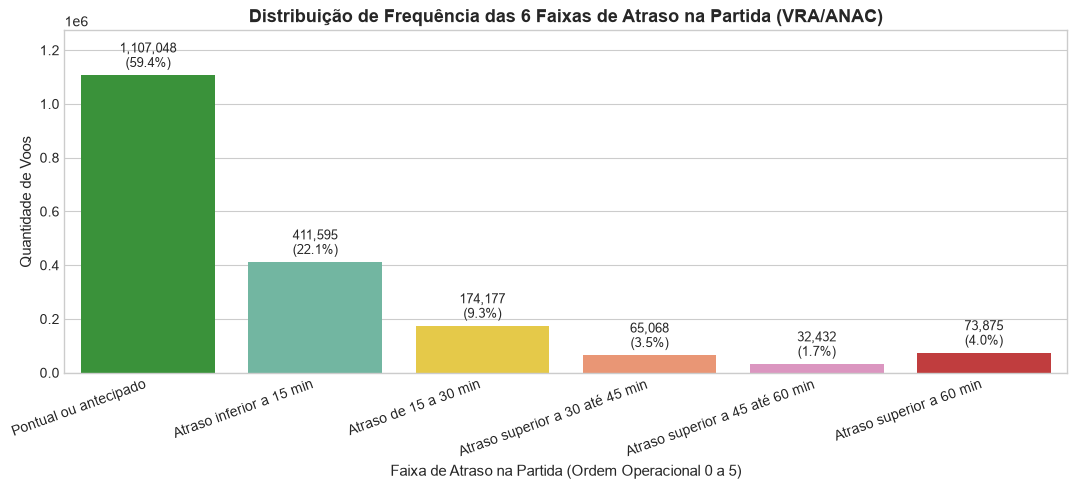

In [6]:
# ==============================================================================
# CÉLULA 10: Distribuição de Frequência das 6 Faixas da Target e Target Binária
# ==============================================================================
ordem_codigos = [0, 1, 2, 3, 4, 5]
ordem_rotulos = [FAIXAS[k] for k in ordem_codigos]

contagem = df['codigo_faixa_atraso'].value_counts().reindex(ordem_codigos, fill_value=0)
proporcao = (contagem / len(df)) * 100

df_dist_target = pd.DataFrame({
    'Código': ordem_codigos,
    'Faixa de Atraso (faixa_atraso_partida)': ordem_rotulos,
    'Quantidade de Voos (N)': contagem.values,
    'Frequência Relativa (%)': proporcao.round(2).values,
    'Frequência Acumulada (%)': proporcao.cumsum().round(2).values
})

print("--- DISTRIBUIÇÃO DA VARIÁVEL TARGET PRINCIPAL (6 FAIXAS ORDINAIS) ---")
display(df_dist_target)

print("\n--- DISTRIBUIÇÃO DA VARIÁVEL TARGET SECUNDÁRIA (atraso_bi: >= 15 min) ---")
cont_bi = df['atraso_bi'].value_counts().reindex([0, 1], fill_value=0)
pct_bi = (cont_bi / len(df) * 100).round(2)
display(pd.DataFrame({
    'Classe Binária': ['0 - Pontual (< 15 min)', '1 - Atrasado (>= 15 min)'],
    'Quantidade (N)': cont_bi.values,
    'Proporção (%)': pct_bi.values
}))

# Visualização Gráfica das 6 Faixas
fig, ax = plt.subplots(figsize=(11, 5))
cores_6_faixas = ['#2ca02c', '#66c2a5', '#ffd92f', '#fc8d62', '#e78ac3', '#d62728']

barras = sns.countplot(
    data=df,
    x='faixa_atraso_partida',
    order=ordem_rotulos,
    palette=cores_6_faixas,
    ax=ax
)

for p in ax.patches:
    altura = int(p.get_height())
    pct = (altura / len(df)) * 100
    ax.annotate(
        f'{altura:,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points'
    )

ax.set_title("Distribuição de Frequência das 6 Faixas de Atraso na Partida (VRA/ANAC)", fontsize=13, fontweight='bold')
ax.set_xlabel("Faixa de Atraso na Partida (Ordem Operacional 0 a 5)", fontsize=11)
ax.set_ylabel("Quantidade de Voos", fontsize=11)
plt.xticks(rotation=20, ha='right')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

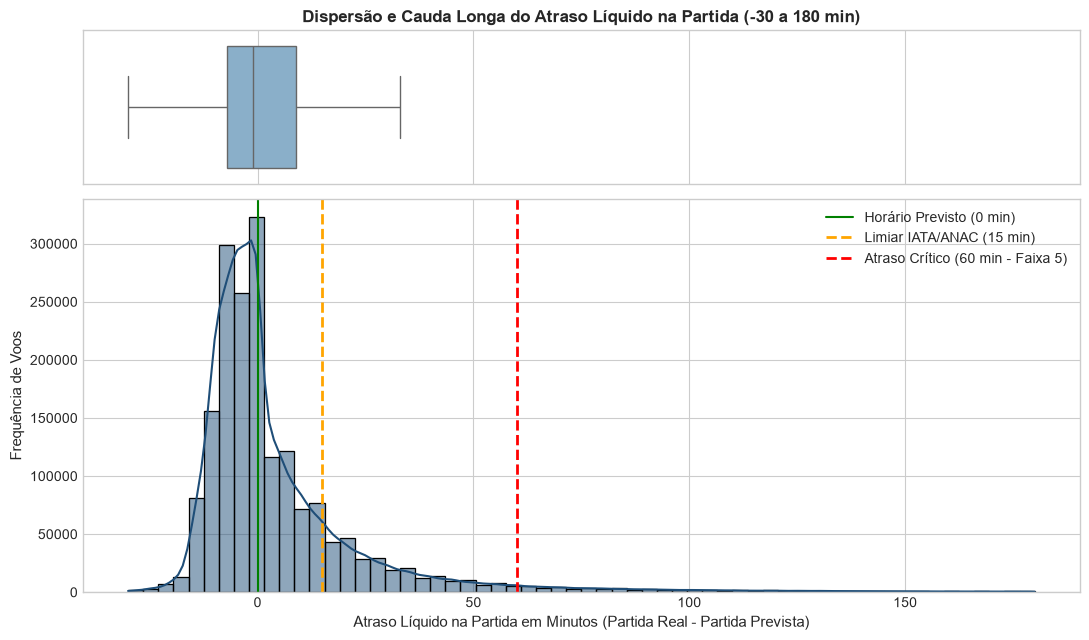

In [7]:
# ==============================================================================
# CÉLULA 11: Visualização de Dispersão e Assimetria (Boxplot + Histograma)
# ==============================================================================
# NOTA METODOLÓGICA: O filtro [-30, 180] minutos é aplicado APENAS ao objeto visual
# 'df_viz' para evitar que outliers extremos (> 10h) comprimam a escala horizontal.
# A base analítica principal 'df' permanece 100% intacta.

df_viz = df[(df['atraso_partida_minutos'] >= -30) & (df['atraso_partida_minutos'] <= 180)]

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={'height_ratios': [0.28, 0.72]}
)

sns.boxplot(x=df_viz['atraso_partida_minutos'], ax=ax_box, color='#80b1d3', showfliers=False)
ax_box.set_title("Dispersão e Cauda Longa do Atraso Líquido na Partida (-30 a 180 min)", fontsize=12, fontweight='bold')
ax_box.set_xlabel("")

sns.histplot(df_viz['atraso_partida_minutos'], bins=60, kde=True, ax=ax_hist, color='#1f4e78')
ax_hist.axvline(0, color='green', linestyle='-', linewidth=1.5, label='Horário Previsto (0 min)')
ax_hist.axvline(15, color='orange', linestyle='--', linewidth=2, label='Limiar IATA/ANAC (15 min)')
ax_hist.axvline(60, color='red', linestyle='--', linewidth=2, label='Atraso Crítico (60 min - Faixa 5)')
ax_hist.set_xlabel("Atraso Líquido na Partida em Minutos (Partida Real - Partida Prevista)", fontsize=11)
ax_hist.set_ylabel("Frequência de Voos", fontsize=11)
ax_hist.legend()

plt.tight_layout()
plt.show()

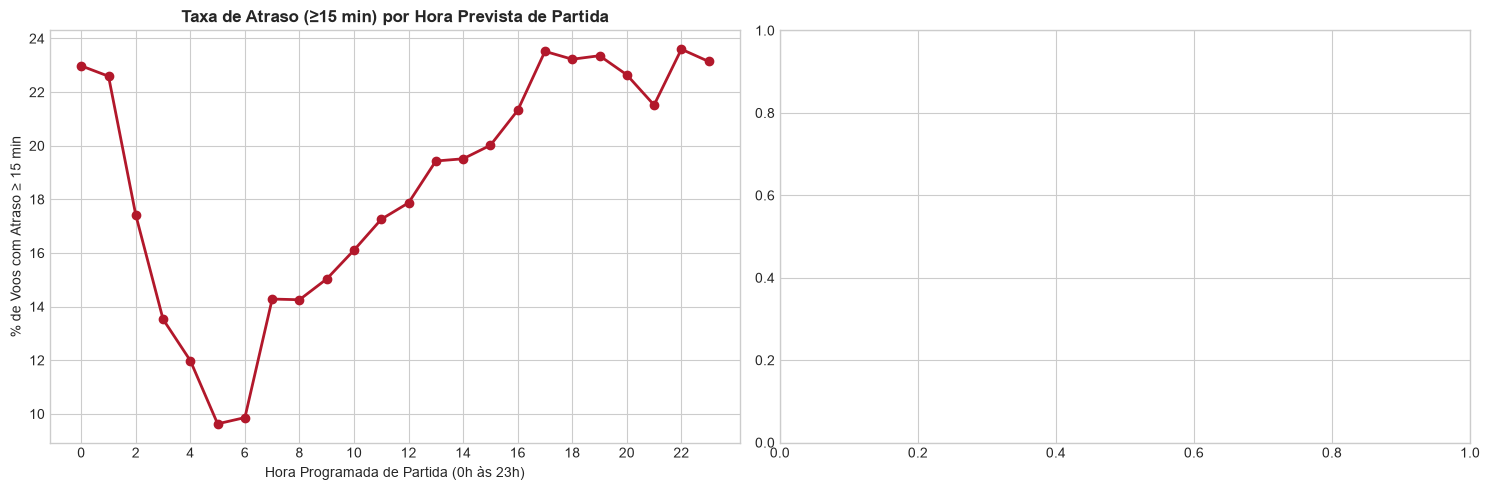

In [8]:
# ==============================================================================
# CÉLULA 12: Exploração Bivariada (Hora Prevista e Companhias Aéreas)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Propagação intradia de atrasos (efeito cascata por hora prevista)
if 'hora_partida_prevista' in df.columns:
    taxa_por_hora = df.groupby('hora_partida_prevista')['atraso_bi'].mean() * 100
    taxa_por_hora.plot(kind='line', marker='o', color='#b2182b', linewidth=2, ax=axes[0])
    axes[0].set_title("Taxa de Atraso (≥15 min) por Hora Prevista de Partida", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Hora Programada de Partida (0h às 23h)")
    axes[0].set_ylabel("% de Voos com Atraso ≥ 15 min")
    axes[0].set_xticks(range(0, 24, 2))

# Gráfico 2: Taxa de atraso entre as 5 companhias aéreas com maior volume de voos
if 'sg_empresa_icao' in df.columns:
    top5_empresas = df['sg_empresa_icao'].value_counts().head(5).index
    df_top5 = df[df['sg_empresa_icao'].isin(top5_empresas)]
    taxa_por_cia = (df_top5.groupby('sg_empresa_icao')['atraso_bi'].mean() * 100).sort_values(ascending=False)
    taxa_por_cia.plot(kind='bar', color='#2b8cbe', ax=axes[1])
    axes[1].set_title("Taxa de Atraso (≥15 min) nas 5 Maiores Companhias Aéreas", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Sigla ICAO da Empresa Aérea")
    axes[1].set_ylabel("% de Voos com Atraso ≥ 15 min")
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# ==============================================================================
# CÉLULA 13: Validação de Paridade com as 19 Variáveis do Dicionário Excel
# ==============================================================================
variaveis_dicionario_19 = [
    'sg_empresa_icao', 'nr_voo', 'sg_icao_origem', 'sg_icao_destino', 'rota',
    'dt_partida_prevista', 'dt_partida_real', 'dt_chegada_prevista', 'dt_chegada_real',
    'ano', 'mes', 'dia_semana', 'hora_partida_prevista', 'minuto_partida_previsto',
    'tempo_voo_planejado_minutos', 'cd_situacao_voo', 'atraso_partida_minutos',
    'faixa_atraso_partida', 'atraso_bi'
]

resumo_auditoria = []
for var in variaveis_dicionario_19:
    existe = var in df.columns
    qtd_nulos = int(df[var].isnull().sum()) if existe else len(df)
    pct_nulos = round((qtd_nulos / len(df)) * 100, 2) if existe else 100.0
    tipo_python = str(df[var].dtype) if existe else 'AUSENTE'
    amostra = str(df[var].dropna().iloc[0]) if (existe and df[var].dropna().shape[0] > 0) else '-'
    resumo_auditoria.append({
        'Ordem': len(resumo_auditoria) + 1,
        'Variável no Dicionário (.xlsx)': var,
        'Presente no DataFrame': 'SIM' if existe else 'NÃO',
        'Tipo Python (dtype)': tipo_python,
        'Qtd Nulos': qtd_nulos,
        '% Nulos': pct_nulos,
        'Exemplo de Valor': amostra
    })

df_paridade = pd.DataFrame(resumo_auditoria)
print("--- TABELA DE PARIDADE: DATAFRAME PYTHON vs. DICIONÁRIO DE DADOS (19 VARIÁVEIS) ---")
display(df_paridade)

--- TABELA DE PARIDADE: DATAFRAME PYTHON vs. DICIONÁRIO DE DADOS (19 VARIÁVEIS) ---


,Ordem,Variável no Dicionário (.xlsx),Presente no DataFrame,Tipo Python (dtype),Qtd Nulos,% Nulos,Exemplo de Valor
0,1,sg_empresa_icao,NÃO,AUSENTE,1864195,100.0,-
1,2,nr_voo,SIM,str,0,0.0,0904
2,3,sg_icao_origem,NÃO,AUSENTE,1864195,100.0,-
3,4,sg_icao_destino,NÃO,AUSENTE,1864195,100.0,-
4,5,rota,NÃO,AUSENTE,1864195,100.0,-
5,6,dt_partida_prevista,SIM,datetime64[us],0,0.0,2024-01-01 23:55:00
6,7,dt_partida_real,SIM,datetime64[us],0,0.0,2024-01-01 23:47:00
7,8,dt_chegada_prevista,SIM,datetime64[us],0,0.0,2024-01-02 07:45:00
8,9,dt_chegada_real,SIM,datetime64[us],0,0.0,2024-01-02 08:19:00
9,10,ano,SIM,int32,0,0.0,2024


## 4. Discussão Preliminar: Qualidade dos Dados e Diretrizes para Modelagem (Atividade 2)
1. **Desbalanceamento Multiclasse Estrutural:** Conforme demonstrado na Célula 10, as faixas `0` (*Pontual ou antecipado*) e `1` (*Atraso inferior a 15 min*) concentram a ampla maioria das operações aéreas regulares, enquanto as faixas `2` a `5` (especialmente a faixa `5` — *Atraso superior a 60 min*) constituem classes minoritárias. Na Atividade 2, o uso isolado da acurácia global seria enganoso, exigindo métricas sensíveis ao desbalanceamento (`Balanced Accuracy`, `F1-Score Macro` e Matriz de Confusão) e ponderação de classes (`class_weight='balanced'`).
2. **Efeito Cascata (*Delay Propagation*):** A análise bivariada (Célula 12) comprova que a probabilidade de atraso cresce sistematicamente a partir do início da manhã até o pico noturno, refletindo o acúmulo de atrasos ao longo das pernas operacionais das aeronaves.
3. **Alta Cardinalidade e Prevenção de *Data Leakage*:** Variáveis como `sg_icao_origem`, `sg_icao_destino` e `rota` possuem alta cardinalidade e deverão ser tratadas na Atividade 2 com esquemas de *Target Encoding out-of-fold* dentro da partição de treino, descartando-se integralmente as variáveis pós-voo (`dt_partida_real`, `dt_chegada_real` e `atraso_partida_minutos`) da matriz preditora $X$.